# 🌸 Flower Classification - ML Pipeline

This notebook demonstrates how to train and evaluate machine learning models for iris flower classification.

**Goal:** Classify iris flowers into 3 species based on 4 features (sepal length/width, petal length/width).

## Setup: Install Dependencies

Run this cell once to install all required packages from requirements.txt:

In [1]:
import subprocess
import sys

# Install the project in editable mode
subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", "."])

0

## 1. Import Required Libraries

In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML Pipeline components
from ml.dataset import Dataset
from ml.models.model_factory import ModelFactory
from ml.trainer import Trainer
from ml.metrics.accuracy import Accuracy
from ml.metrics.confusion_matrix import ConfusionMatrix

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Load the Dataset

In [3]:
# Create dataset with custom test size
test_size = 0.3
random_state = 42

dataset = Dataset(test_size=test_size, random_state=random_state)
dataset.load_data()

x_train, y_train = dataset.get_train_data()
x_test, y_test = dataset.get_test_data()

print(f"✓ Dataset loaded:")
print(f"  Training samples: {len(x_train)}")
print(f"  Testing samples: {len(x_test)}")
print(f"  Features: {list(x_train.columns)}")
print(f"  Classes: {sorted(y_train.unique())}")

✓ Dataset loaded:
  Training samples: 105
  Testing samples: 45
  Features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
  Classes: ['setosa', 'versicolor', 'virginica']


## 3. Explore the Data

In [4]:
# Display first few samples
print("Training Data Sample:")
print(x_train.head())
print(f"\nTarget Distribution:\n{y_train.value_counts()}")

Training Data Sample:
     sepal_length  sepal_width  petal_length  petal_width
81            5.5          2.4           3.7          1.0
133           6.3          2.8           5.1          1.5
137           6.4          3.1           5.5          1.8
75            6.6          3.0           4.4          1.4
109           7.2          3.6           6.1          2.5

Target Distribution:
species
versicolor    37
virginica     37
setosa        31
Name: count, dtype: int64


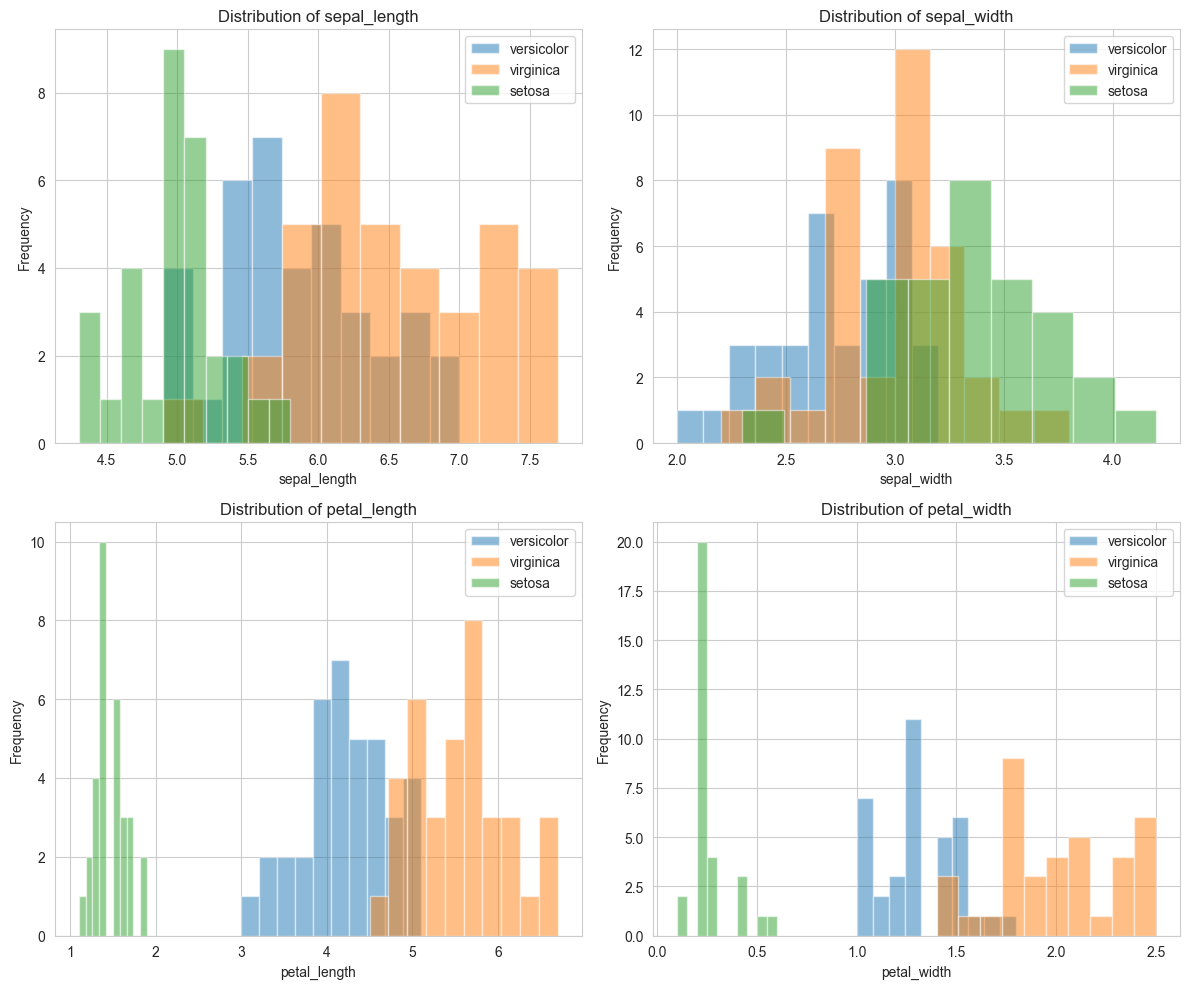

In [5]:
# Visualize feature distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = x_train.columns

for idx, feature in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    for species in y_train.unique():
        mask = y_train == species
        ax.hist(x_train[mask][feature], alpha=0.5, label=species)
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution of {feature}")
    ax.legend()

plt.tight_layout()
plt.show()

## 4. Train Different Models

Let's compare all 8 available models:

In [6]:
# List all available models
available_models = [
    "svm_linear",
    "svm_rbf",
    "svm_poly",
    "svm_sigmoid",
    "decision_tree",
    "knn",
    "random_forest",
    "lda"
]

# Train all models and store results
results = {}

for model_name in available_models:
    print(f"\nTraining {model_name}...")
    
    # Create model from factory
    model = ModelFactory.get_model(model_name, input_shape=4, output_shape=3)
    
    # Initialize metrics
    metrics = [Accuracy()]
    
    # Train
    trainer = Trainer(model=model, dataset=dataset, metrics_list=metrics, epochs=1)
    trainer.train()
    
    # Evaluate
    evaluation = trainer.evaluate()
    accuracy = evaluation['Accuracy']
    results[model_name] = accuracy
    
    print(f"  ✓ Accuracy: {accuracy:.4f}")

print("\n" + "="*50)
print("Training completed for all models!")


Training svm_linear...
Training completed.
  ✓ Accuracy: 1.0000

Training svm_rbf...
Training completed.
  ✓ Accuracy: 1.0000

Training svm_poly...
Training completed.
  ✓ Accuracy: 0.9778

Training svm_sigmoid...
Training completed.
  ✓ Accuracy: 0.2222

Training decision_tree...
Training completed.
  ✓ Accuracy: 1.0000

Training knn...
Training completed.
  ✓ Accuracy: 1.0000

Training random_forest...
Training completed.
  ✓ Accuracy: 1.0000

Training lda...
Training completed.
  ✓ Accuracy: 1.0000

Training completed for all models!


## 5. Compare Model Performance

In [7]:
# Sort results by accuracy
sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

# Display results
print("\n--- Model Rankings ---")
for rank, (model_name, accuracy) in enumerate(sorted_results.items(), 1):
    print(f"{rank}. {model_name:20} - Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")


--- Model Rankings ---
1. svm_linear           - Accuracy: 1.0000 (100.00%)
2. svm_rbf              - Accuracy: 1.0000 (100.00%)
3. decision_tree        - Accuracy: 1.0000 (100.00%)
4. knn                  - Accuracy: 1.0000 (100.00%)
5. random_forest        - Accuracy: 1.0000 (100.00%)
6. lda                  - Accuracy: 1.0000 (100.00%)
7. svm_poly             - Accuracy: 0.9778 (97.78%)
8. svm_sigmoid          - Accuracy: 0.2222 (22.22%)


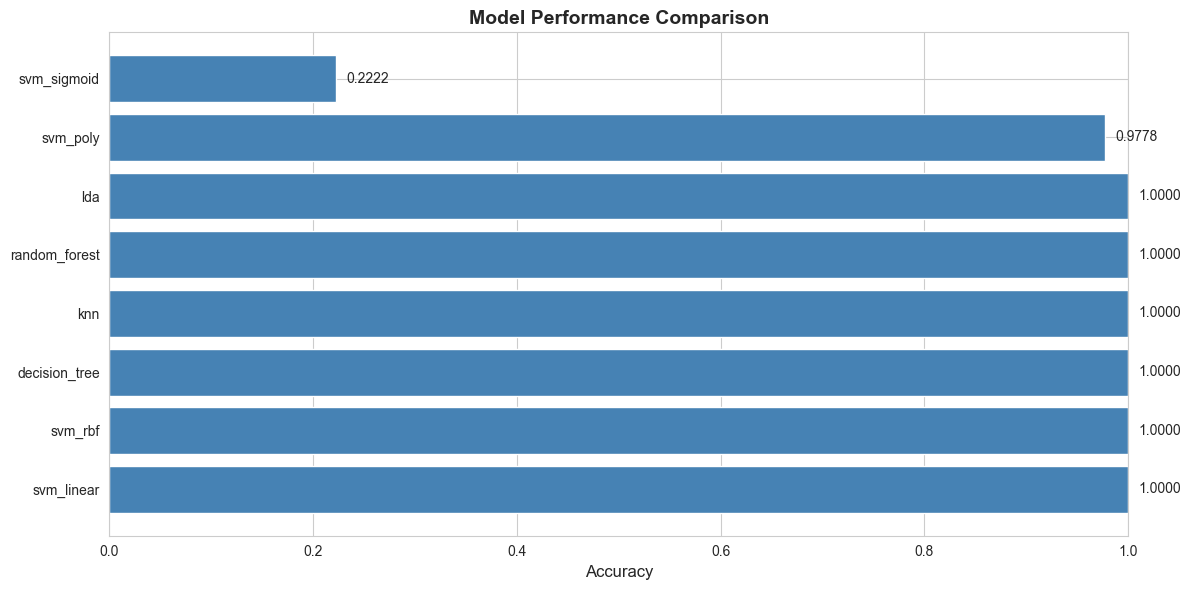

In [8]:
# Visualize model comparison
fig, ax = plt.subplots(figsize=(12, 6))

models = list(sorted_results.keys())
accuracies = list(sorted_results.values())

bars = ax.barh(models, accuracies, color='steelblue')
ax.set_xlabel('Accuracy', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xlim([0, 1])

# Add value labels on bars
for bar, accuracy in zip(bars, accuracies):
    ax.text(accuracy + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{accuracy:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 6. Detailed Analysis of Best Model

In [9]:
# Get the best model
best_model_name = list(sorted_results.keys())[0]
print(f"Best Model: {best_model_name}")
print(f"Accuracy: {sorted_results[best_model_name]:.4f}\n")

# Retrain best model with confusion matrix
best_model = ModelFactory.get_model(best_model_name, input_shape=4, output_shape=3)
metrics = [Accuracy(), ConfusionMatrix()]

trainer = Trainer(model=best_model, dataset=dataset, metrics_list=metrics, epochs=1)
trainer.train()

results_best = trainer.evaluate()
print(results_best['Confusion Matrix'])

Best Model: svm_linear
Accuracy: 1.0000

Training completed.
setosa       -> Corret: 19 | Incorrect:  0
versicolor   -> Corret: 13 | Incorrect:  0
virginica    -> Corret: 13 | Incorrect:  0


## 7. Make Predictions on New Data

In [10]:
# Get predictions on test data
x_test_data, y_test_data = dataset.get_test_data()
predictions = best_model.predict(x_test_data)

# Display some predictions
sample_indices = np.random.choice(len(predictions), 10, replace=False)

prediction_df = pd.DataFrame({
    'True Label': y_test_data.iloc[sample_indices].values,
    'Prediction': predictions[sample_indices],
    'Correct': y_test_data.iloc[sample_indices].values == predictions[sample_indices]
})

print("Sample Predictions:")
print(prediction_df.to_string())

Sample Predictions:
   True Label  Prediction  Correct
0      setosa      setosa     True
1      setosa      setosa     True
2      setosa      setosa     True
3  versicolor  versicolor     True
4  versicolor  versicolor     True
5      setosa      setosa     True
6      setosa      setosa     True
7  versicolor  versicolor     True
8      setosa      setosa     True
9  versicolor  versicolor     True


## Summary

✓ Successfully demonstrated the ML Pipeline!

**Key Takeaways:**
- Loaded and explored the Iris dataset
- Trained 8 different ML models
- Compared model performance
- Evaluated the best model with detailed metrics
- Made predictions on new data

**Next Steps:**
- Experiment with hyperparameters
- Try feature scaling or normalization
- Implement cross-validation
- Create an ensemble of multiple models